In [1]:
!pip install -q kaggle wandb onnx onnxruntime onnxscript
from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 9.2 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/MLassignment4/MLassignment4/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
!unzip -q -o challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d data
!ls -lh data

100% 285M/285M [00:02<00:00, 136MB/s]

total 667M
-rw-r--r-- 1 root root 7.1K Dec 11  2019 example_submission.csv
-rw-r--r-- 1 root root  92M Dec 11  2019 fer2013.tar.gz
-rw-r--r-- 1 root root 288M Dec 11  2019 icml_face_data.csv
-rw-r--r-- 1 root root  58M Dec 11  2019 test.csv
-rw-r--r-- 1 root root 230M Dec 11  2019 train.csv


In [3]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: smama23 (smama23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
import copy
import torch
from torch import nn
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device available:", device)

Device available: cuda


In [5]:
PROJECT = "fer2013-emotion-recognition"
EMOTIONS = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

CONFIG = {
    "arch": "VGG-CNN",
    "epochs": 60,
    "batch_size": 64,
    "lr": 1e-3,
    "optimizer": "Adam",
    "weight_decay": 1e-4,
    "dropout": 0.4,
    "augment": True,
    "scheduler": True,
    "patience": 10,
    "class_weights": False,
    "num_classes": 7,
}
CONFIG

{'arch': 'VGG-CNN',
 'epochs': 60,
 'batch_size': 64,
 'lr': 0.001,
 'optimizer': 'Adam',
 'weight_decay': 0.0001,
 'dropout': 0.4,
 'augment': True,
 'scheduler': True,
 'patience': 10,
 'class_weights': False,
 'num_classes': 7}

In [6]:
df = pd.read_csv("data/icml_face_data.csv")
df.columns = df.columns.str.strip()

def parse_pixels(series):
    return np.stack([np.array(p.split(), dtype=np.uint8).reshape(48, 48) for p in series])

def split_xy(frame):
    return parse_pixels(frame['pixels']), frame['emotion'].to_numpy(dtype=np.int64)

X_train, y_train = split_xy(df[df['Usage'] == 'Training'])
X_val,   y_val   = split_xy(df[df['Usage'] == 'PublicTest'])
X_test,  y_test  = split_xy(df[df['Usage'] == 'PrivateTest'])
print("train:", X_train.shape, "| val:", X_val.shape, "| test:", X_test.shape)

train: (28709, 48, 48) | val: (3589, 48, 48) | test: (3589, 48, 48)


In [7]:
class FERDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.images, self.labels, self.transform = images, labels, transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, i):
        return self.transform(Image.fromarray(self.images[i])), int(self.labels[i])


def build_transforms(augment):
    base = [transforms.ToTensor(), transforms.Normalize([0.5], [0.5])]
    if augment:
        return transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
        ] + base)
    return transforms.Compose(base)


def build_loaders(config):
    train_tf, eval_tf = build_transforms(config["augment"]), build_transforms(False)
    bs = config["batch_size"]
    return (
        DataLoader(FERDataset(X_train, y_train, train_tf), batch_size=bs, shuffle=True,  num_workers=2, pin_memory=True),
        DataLoader(FERDataset(X_val,   y_val,   eval_tf),  batch_size=bs, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(FERDataset(X_test,  y_test,  eval_tf),  batch_size=bs, shuffle=False, num_workers=2, pin_memory=True),
    )

counts = np.bincount(y_train, minlength=7)
CLASS_WEIGHTS = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float32)
print("class weights:", {EMOTIONS[i]: round(float(w), 2) for i, w in enumerate(CLASS_WEIGHTS)})

class weights: {'Angry': 1.03, 'Disgust': 9.41, 'Fear': 1.0, 'Happy': 0.57, 'Sad': 0.85, 'Surprise': 1.29, 'Neutral': 0.83}


In [8]:
class VGGStyleCNN(nn.Module):
    def __init__(self, num_classes=7, dropout=0.4):
        super().__init__()
        def block(cin, cout, p):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                nn.MaxPool2d(2), nn.Dropout(p),
            )
        self.features = nn.Sequential(
            block(1,   64,  dropout * 0.5),   # 48 -> 24
            block(64,  128, dropout * 0.5),   # 24 -> 12
            block(128, 256, dropout * 0.75),  # 12 -> 6
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))


def build_model(config):
    return VGGStyleCNN(num_classes=config["num_classes"], dropout=config["dropout"])

_m = build_model(CONFIG)
print("Trainable params:", sum(p.numel() for p in _m.parameters() if p.requires_grad))

Trainable params: 3507911


In [9]:
model = build_model(CONFIG).to(device)
out = model(torch.randn(8, 1, 48, 48, device=device))
print("forward output shape:", out.shape); assert out.shape == (8, 7)
print("Forward check passed.")

forward output shape: torch.Size([8, 7])
Forward check passed.


In [10]:
model = build_model(CONFIG).to(device)
criterion = nn.CrossEntropyLoss(); optimizer = Adam(model.parameters(), lr=1e-3)
train_loader, val_loader, test_loader = build_loaders(CONFIG)
ob_x, ob_y = next(iter(train_loader)); ob_x, ob_y = ob_x[:32].to(device), ob_y[:32].to(device)
model.train()
for step in range(200):
    optimizer.zero_grad(); loss = criterion(model(ob_x), ob_y); loss.backward(); optimizer.step()
    if step % 40 == 0 or step == 199:
        acc = (model(ob_x).argmax(1) == ob_y).float().mean().item()
        print(f"step {step:3d} | loss {loss.item():.4f} | batch acc {acc:.2f}")
print("Backward check passed if loss -> ~0 and acc -> 1.0")

step   0 | loss 1.9610 | batch acc 0.50
step  40 | loss 0.0139 | batch acc 1.00
step  80 | loss 0.0053 | batch acc 1.00
step 120 | loss 0.0035 | batch acc 1.00
step 160 | loss 0.0021 | batch acc 1.00
step 199 | loss 0.0019 | batch acc 1.00
Backward check passed if loss -> ~0 and acc -> 1.0


In [11]:
def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train: optimizer.zero_grad()
            logits = model(x); loss = criterion(logits, y)
            if train: loss.backward(); optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item(); n += x.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def collect_preds(model, loader):
    model.eval(); preds, targets = [], []
    for x, y in loader:
        preds.append(model(x.to(device)).argmax(1).cpu()); targets.append(y)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

In [12]:
def run_experiment(config, run_name):
    train_loader, val_loader, test_loader = build_loaders(config)
    run = wandb.init(project=PROJECT, name=run_name, group=config["arch"], config=config, reinit=True)

    model = build_model(config).to(device)
    wandb.watch(model, log="all", log_freq=200)
    weight = CLASS_WEIGHTS.to(device) if config.get("class_weights") else None
    criterion = nn.CrossEntropyLoss(weight=weight)
    opt_cls = SGD if config["optimizer"] == "SGD" else Adam
    opt_kwargs = {"momentum": 0.9} if config["optimizer"] == "SGD" else {}
    optimizer = opt_cls(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"], **opt_kwargs)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3) if config["scheduler"] else None

    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
    best_val_loss, best_val_acc, best_state, bad = float("inf"), 0.0, None, 0
    for epoch in range(config["epochs"]):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)
        if scheduler: scheduler.step(va_loss)
        best_val_acc = max(best_val_acc, va_acc)
        lr_now = optimizer.param_groups[0]["lr"]
        wandb.log({"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc,
                   "val_loss": va_loss, "val_acc": va_acc, "lr": lr_now})
        for k, v in zip(history, [tr_acc, va_acc, tr_loss, va_loss]): history[k].append(v)
        print(f"epoch {epoch+1:2d}/{config['epochs']} | train_loss {tr_loss:.3f} acc {tr_acc:.3f} | "
              f"val_loss {va_loss:.3f} acc {va_acc:.3f} | lr {lr_now:.1e}")

        if va_loss < best_val_loss - 1e-4:
            best_val_loss, best_state, bad = va_loss, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
            if bad >= config["patience"]:
                print(f"Early stopping at epoch {epoch+1} (no val-loss improvement for {bad}).")
                break

    if best_state is not None: model.load_state_dict(best_state)

    te_loss, te_acc = run_epoch(model, test_loader, criterion)
    preds, targets = collect_preds(model, test_loader)
    print(f"\nPrivateTest accuracy (best weights): {te_acc:.4f}")
    print(classification_report(targets, preds, target_names=EMOTIONS, digits=3))

    wandb.summary["test_acc"] = te_acc
    wandb.summary["test_loss"] = te_loss
    wandb.summary["best_val_acc"] = best_val_acc
    wandb.summary["epochs_run"] = len(history["train_acc"])
    wandb.summary["overfit_gap"] = max(history["train_acc"]) - best_val_acc
    wandb.log({"confusion_matrix": wandb.plot.confusion_matrix(
        y_true=targets, preds=preds, class_names=EMOTIONS)})

    try:
        model_file = f"{run_name}.onnx"
        torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), model_file,
                          input_names=["input"], output_names=["logits"],
                          dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}}, dynamo=False)
    except Exception as e:
        print(f"ONNX export failed ({e}); saving .pth instead.")
        model_file = f"{run_name}.pth"; torch.save(model.state_dict(), model_file)
    art = wandb.Artifact(run_name, type="model", metadata={"test_acc": te_acc})
    art.add_file(model_file); run.log_artifact(art)

    run.finish()
    return model, history, te_acc

In [13]:
model, history, test_acc = run_experiment(CONFIG, run_name="VGG-CNN-full-lr0.001-bs64")

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


epoch  1/60 | train_loss 1.606 acc 0.369 | val_loss 1.391 acc 0.464 | lr 1.0e-03
epoch  2/60 | train_loss 1.332 acc 0.487 | val_loss 1.224 acc 0.526 | lr 1.0e-03
epoch  3/60 | train_loss 1.238 acc 0.529 | val_loss 1.202 acc 0.542 | lr 1.0e-03
epoch  4/60 | train_loss 1.196 acc 0.545 | val_loss 1.149 acc 0.560 | lr 1.0e-03
epoch  5/60 | train_loss 1.159 acc 0.558 | val_loss 1.115 acc 0.579 | lr 1.0e-03
epoch  6/60 | train_loss 1.131 acc 0.571 | val_loss 1.068 acc 0.595 | lr 1.0e-03
epoch  7/60 | train_loss 1.112 acc 0.581 | val_loss 1.038 acc 0.598 | lr 1.0e-03
epoch  8/60 | train_loss 1.087 acc 0.589 | val_loss 1.054 acc 0.605 | lr 1.0e-03
epoch  9/60 | train_loss 1.075 acc 0.593 | val_loss 1.043 acc 0.600 | lr 1.0e-03
epoch 10/60 | train_loss 1.060 acc 0.599 | val_loss 1.012 acc 0.615 | lr 1.0e-03
epoch 11/60 | train_loss 1.048 acc 0.604 | val_loss 1.023 acc 0.616 | lr 1.0e-03
epoch 12/60 | train_loss 1.031 acc 0.612 | val_loss 1.047 acc 0.604 | lr 1.0e-03
epoch 13/60 | train_loss 1.0

/tmp/ipykernel_646/3714661674.py:53: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), model_file,


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,████████████████████▄▄▄▄▄▄▄▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇██████
train_loss,█▆▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▃▃▄▅▅▅▅▅▆▆▅▆▆▆▆▆▆▇▆▇▇▇▇▇▇▇████████████
val_loss,█▆▅▅▄▄▃▃▃▃▃▃▂▂▂▂▂▃▂▃▂▁▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.68821
epoch,38
epochs_run,39
lr,6e-05
overfit_gap,0.05431


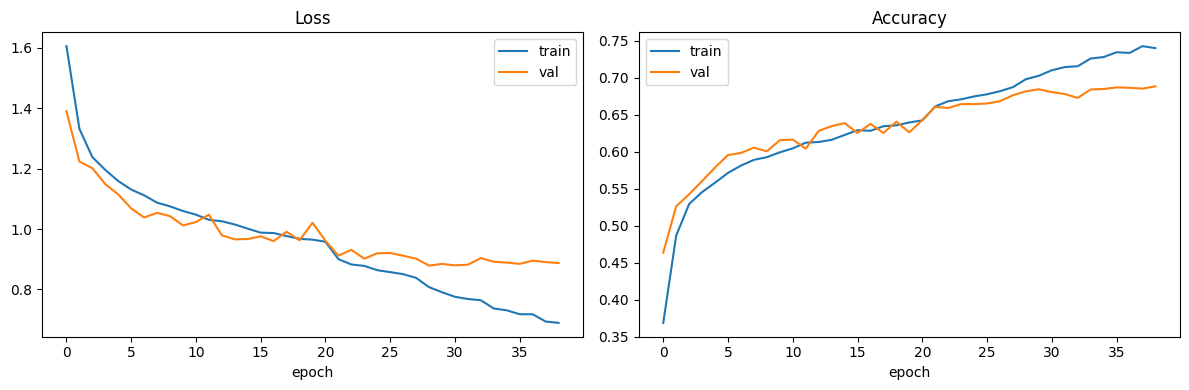

max train acc 0.743 | max val acc 0.688 | gap 0.054


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["train_acc"], label="train"); ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"max train acc {max(history['train_acc']):.3f} | max val acc {max(history['val_acc']):.3f} | "
      f"gap {max(history['train_acc']) - max(history['val_acc']):.3f}")

In [19]:
ablations = {
    "VGG-CNN-noaug":        {**CONFIG, "augment": False},
    "VGG-CNN-noreg":        {**CONFIG, "dropout": 0.0, "weight_decay": 0.0},
    "VGG-CNN-classweights": {**CONFIG, "class_weights": True},
}

results = {"VGG-CNN-full-lr0.001-bs64": test_acc}
for name, cfg in ablations.items():
    cfg = {**cfg, "epochs": 25, "patience": 6}
    _, _, acc = run_experiment(cfg, run_name=name)
    results[name] = acc

for k, v in sorted(results.items(), key=lambda kv: -kv[1]):
    print(f"{v:.4f}  {k}")

epoch  1/25 | train_loss 1.442 acc 0.441 | val_loss 1.275 acc 0.512 | lr 1.0e-03
epoch  2/25 | train_loss 1.192 acc 0.544 | val_loss 1.178 acc 0.547 | lr 1.0e-03
epoch  3/25 | train_loss 1.108 acc 0.581 | val_loss 1.099 acc 0.576 | lr 1.0e-03
epoch  4/25 | train_loss 1.038 acc 0.606 | val_loss 1.043 acc 0.608 | lr 1.0e-03
epoch  5/25 | train_loss 0.983 acc 0.630 | val_loss 1.050 acc 0.602 | lr 1.0e-03
epoch  6/25 | train_loss 0.943 acc 0.647 | val_loss 1.035 acc 0.613 | lr 1.0e-03
epoch  7/25 | train_loss 0.892 acc 0.665 | val_loss 1.010 acc 0.618 | lr 1.0e-03
epoch  8/25 | train_loss 0.849 acc 0.683 | val_loss 0.989 acc 0.628 | lr 1.0e-03
epoch  9/25 | train_loss 0.806 acc 0.699 | val_loss 1.012 acc 0.632 | lr 1.0e-03
epoch 10/25 | train_loss 0.762 acc 0.717 | val_loss 1.017 acc 0.639 | lr 1.0e-03
epoch 11/25 | train_loss 0.713 acc 0.734 | val_loss 1.029 acc 0.634 | lr 1.0e-03
epoch 12/25 | train_loss 0.658 acc 0.755 | val_loss 1.059 acc 0.633 | lr 5.0e-04
epoch 13/25 | train_loss 0.5

/tmp/ipykernel_646/3714661674.py:53: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), model_file,


epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
lr,███████████▁▁▁
train_acc,▁▃▃▄▄▅▅▅▅▆▆▆██
train_loss,█▆▆▅▅▅▄▄▄▃▃▃▂▁
val_acc,▁▃▄▅▅▆▆▆▇▇▇▇▇█
val_loss,█▆▄▂▂▂▂▁▂▂▂▃▃▄
best_val_acc,0.66369
epoch,13
epochs_run,14
lr,0.0005
overfit_gap,0.18228


epoch  1/25 | train_loss 1.531 acc 0.395 | val_loss 1.340 acc 0.487 | lr 1.0e-03
epoch  2/25 | train_loss 1.268 acc 0.515 | val_loss 1.182 acc 0.549 | lr 1.0e-03
epoch  3/25 | train_loss 1.162 acc 0.559 | val_loss 1.122 acc 0.568 | lr 1.0e-03
epoch  4/25 | train_loss 1.102 acc 0.581 | val_loss 1.072 acc 0.593 | lr 1.0e-03
epoch  5/25 | train_loss 1.054 acc 0.600 | val_loss 1.101 acc 0.595 | lr 1.0e-03
epoch  6/25 | train_loss 1.023 acc 0.612 | val_loss 1.066 acc 0.595 | lr 1.0e-03
epoch  7/25 | train_loss 0.995 acc 0.624 | val_loss 1.033 acc 0.617 | lr 1.0e-03
epoch  8/25 | train_loss 0.971 acc 0.634 | val_loss 1.009 acc 0.622 | lr 1.0e-03
epoch  9/25 | train_loss 0.945 acc 0.644 | val_loss 0.999 acc 0.631 | lr 1.0e-03
epoch 10/25 | train_loss 0.924 acc 0.652 | val_loss 1.045 acc 0.622 | lr 1.0e-03
epoch 11/25 | train_loss 0.898 acc 0.660 | val_loss 0.995 acc 0.636 | lr 1.0e-03
epoch 12/25 | train_loss 0.877 acc 0.669 | val_loss 0.985 acc 0.634 | lr 1.0e-03
epoch 13/25 | train_loss 0.8

/tmp/ipykernel_646/3714661674.py:53: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), model_file,


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,██████████████████▁▁▁▁▁▁▁
train_acc,▁▃▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇█████
train_loss,█▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▁▁▁▁
val_acc,▁▃▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███▇██
val_loss,█▅▄▃▄▃▃▂▂▃▂▂▁▁▁▁▁▂▂▁▁▁▁▂▂
best_val_acc,0.68069
epoch,24
epochs_run,25
lr,0.0005
overfit_gap,0.10453


epoch  1/25 | train_loss 1.883 acc 0.237 | val_loss 1.673 acc 0.327 | lr 1.0e-03
epoch  2/25 | train_loss 1.596 acc 0.392 | val_loss 1.381 acc 0.467 | lr 1.0e-03
epoch  3/25 | train_loss 1.460 acc 0.447 | val_loss 1.446 acc 0.451 | lr 1.0e-03
epoch  4/25 | train_loss 1.393 acc 0.477 | val_loss 1.294 acc 0.510 | lr 1.0e-03
epoch  5/25 | train_loss 1.335 acc 0.495 | val_loss 1.261 acc 0.495 | lr 1.0e-03
epoch  6/25 | train_loss 1.306 acc 0.508 | val_loss 1.234 acc 0.529 | lr 1.0e-03
epoch  7/25 | train_loss 1.274 acc 0.520 | val_loss 1.220 acc 0.561 | lr 1.0e-03
epoch  8/25 | train_loss 1.248 acc 0.528 | val_loss 1.213 acc 0.537 | lr 1.0e-03
epoch  9/25 | train_loss 1.225 acc 0.534 | val_loss 1.205 acc 0.555 | lr 1.0e-03
epoch 10/25 | train_loss 1.207 acc 0.538 | val_loss 1.148 acc 0.575 | lr 1.0e-03
epoch 11/25 | train_loss 1.176 acc 0.551 | val_loss 1.146 acc 0.575 | lr 1.0e-03
epoch 12/25 | train_loss 1.169 acc 0.554 | val_loss 1.120 acc 0.575 | lr 1.0e-03
epoch 13/25 | train_loss 1.1

/tmp/ipykernel_646/3714661674.py:53: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), model_file,


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,███████████████████████▁▁
train_acc,▁▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██▇███
train_loss,█▆▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▁
val_acc,▁▄▄▅▅▆▆▆▆▇▇▇▆▇▇▇▇▇█▇▇██▇█
val_loss,█▅▆▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▂▂▁
best_val_acc,0.63193
epoch,24
epochs_run,25
lr,0.0005
overfit_gap,-0.01449


0.6963  VGG-CNN-noreg
0.6957  VGG-CNN-full-lr0.001-bs64
0.6643  VGG-CNN-classweights
0.6447  VGG-CNN-noaug


In [20]:
test_df = pd.read_csv("data/test.csv")
X_kaggle = parse_pixels(test_df['pixels'])
kaggle_loader = DataLoader(FERDataset(X_kaggle, np.zeros(len(X_kaggle), np.int64), build_transforms(False)),
                           batch_size=128, shuffle=False)
kaggle_preds, _ = collect_preds(model, kaggle_loader)
pd.Series(kaggle_preds).to_csv("submission_vgg.csv", index=False, header=False)
print("Wrote submission_vgg.csv with", len(kaggle_preds), "predictions")

Wrote submission_vgg.csv with 7178 predictions
